# Carbon-24 — Phát Hiện Dị Biệt (Anomaly Detection)

## Nguyên tắc thiết kế

| Bước | Input | Mục đích |
|------|-------|----------|
| Phát hiện | Features **cấu trúc** (lattice, bond, coordination) | Tìm cấu trúc bất thường về hình học |
| Diễn giải | `relative_energy` | Xác nhận ý nghĩa vật lý |

> **Quan trọng:** `energy` / `relative_energy` **không** được đưa vào input phát hiện để tránh data leakage.

## 3 Phương pháp

1. **HDBSCAN Noise** — cluster = -1: cấu trúc không thuộc cụm nào → hình học bất thường
2. **Low Membership Probability** — prob < 0.5: nằm ở biên cụm, không điển hình
3. **Isolation Forest** — trên 19 features cấu trúc gốc: outlier đa chiều trong feature space

## Kết hợp
- **Consensus (≥2/3)**: cân bằng precision/recall — khuyến nghị cho lọc dữ liệu
- **All 3**: độ tin cậy cao nhất — dùng cho phân tích sâu

## 1. Setup & Chạy Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display as ipy_display

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Chạy toàn bộ pipeline
import carbon24_anomaly_detection
carbon24_anomaly_detection.main()


CARBON-24 ANOMALY DETECTION
Nguyên tắc: features cấu trúc → phát hiện → diễn giải bằng energy
✅ Output dir: c:\bda_env\venv\Scripts\DATAMINING\carbon24_anomaly_detection
✅ HDBSCAN results: (10153, 17)  |  cols: ['row_index', 'material_id', 'split', 'source_file', 'formula', 'elements', 'space_group_number', 'space_group_symbol', 'crystal_system', 'energy', 'energy_per_atom', 'relative_energy', 'hdbscan_cluster', 'hdbscan_probability', 'hdbscan_is_noise', 'pca1', 'pca2']
✅ Features file: c:\bda_env\venv\Scripts\DATAMINING\carbon24_features\carbon24_project\data\carbon24_features.csv  |  19 structure features

PHƯƠNG PHÁP 1: HDBSCAN NOISE  (cluster = -1)
  Noise points : 786 / 10,153  (7.74%)
  Ý nghĩa      : cấu trúc không thuộc cụm nào → hình học bất thường

PHƯƠNG PHÁP 2: LOW MEMBERSHIP PROBABILITY  (< 0.5)
  Low-prob points : 800 / 10,153  (7.88%)
  Probability stats:
count    10153.000000
mean         0.866841
std          0.267649
min          0.000000
25%          0.860512
50%   

## 2. Load Kết Quả

In [2]:
OUT = Path('carbon24_anomaly_detection')

results_df    = pd.read_csv(OUT / 'anomaly_detection_results.csv')
summary_df    = pd.read_csv(OUT / 'anomaly_summary.csv')
comparison_df = pd.read_csv(OUT / 'anomaly_method_comparison.csv')
details_df    = pd.read_csv(OUT / 'anomaly_details.csv')

print(f'Shape: {results_df.shape}')
print(f'Columns: {results_df.columns.tolist()}')
results_df.head(3)

Shape: (10153, 26)
Columns: ['row_index', 'material_id', 'split', 'source_file', 'formula', 'elements', 'space_group_number', 'space_group_symbol', 'crystal_system', 'energy', 'energy_per_atom', 'relative_energy', 'hdbscan_cluster', 'hdbscan_probability', 'hdbscan_is_noise', 'pca1', 'pca2', 'is_hdbscan_noise', 'is_low_probability', 'is_isolation_forest_anomaly', 'isolation_forest_score', 'isolation_forest_used_pca', 'anomaly_vote_count', 'is_anomaly_any', 'is_anomaly_consensus', 'is_anomaly_all']


,row_index,material_id,split,source_file,formula,elements,space_group_number,space_group_symbol,crystal_system,energy,...,pca2,is_hdbscan_noise,is_low_probability,is_isolation_forest_anomaly,isolation_forest_score,isolation_forest_used_pca,anomaly_vote_count,is_anomaly_any,is_anomaly_consensus,is_anomaly_all
0,0,C-130499-1826-36,train,huggingface,C,C,12,C2/m,monoclinic,-154.311891,...,2.212702,0,0,0,-0.522226,0,0,0,0,0
1,1,C-13904-4247-31,train,huggingface,C,C,12,C2/m,monoclinic,-154.332183,...,2.080668,0,0,0,-0.443967,0,0,0,0,0
2,2,C-92138-4782-35,train,huggingface,C,C,8,Cm,monoclinic,-154.178157,...,0.766559,0,0,0,-0.450484,0,0,0,0,0


## 3. Tổng Quan — Số Lượng Anomalies

In [3]:
print('=' * 65)
print('TỔNG QUAN ANOMALY DETECTION')
print('=' * 65)
print(f'  Tổng số mẫu         : {len(results_df):,}')
print()
for col, label in [
    ('is_hdbscan_noise',            'HDBSCAN Noise          '),
    ('is_low_probability',          'Low Probability        '),
    ('is_isolation_forest_anomaly', 'Isolation Forest       '),
    ('is_anomaly_any',              'Any method (≥1)        '),
    ('is_anomaly_consensus',        'Consensus (≥2) ★       '),
    ('is_anomaly_all',              'All 3 methods          '),
]:
    n = results_df[col].sum()
    r = results_df[col].mean()
    print(f'  {label}: {n:>5,}  ({r:.2%})')

TỔNG QUAN ANOMALY DETECTION
  Tổng số mẫu         : 10,153

  HDBSCAN Noise          :   786  (7.74%)
  Low Probability        :   800  (7.88%)
  Isolation Forest       :   782  (7.70%)
  Any method (≥1)        : 1,181  (11.63%)
  Consensus (≥2) ★       :   799  (7.87%)
  All 3 methods          :   388  (3.82%)


## 4. So Sánh Các Phương Pháp

In [4]:
display(comparison_df.style
    .format({'anomaly_ratio': '{:.2%}', 'normal_ratio': '{:.2%}'})
    .bar(subset=['anomaly_ratio'], color='#e74c3c', vmin=0, vmax=0.2)
    .set_caption('Anomaly Detection — Method Comparison')
)

,method,n_anomalies,anomaly_ratio,n_normal,normal_ratio
0,is_hdbscan_noise,786,7.74%,9367,92.26%
1,is_low_probability,800,7.88%,9353,92.12%
2,is_isolation_forest_anomaly,782,7.70%,9371,92.30%
3,is_anomaly_consensus,799,7.87%,9354,92.13%
4,is_anomaly_any,1181,11.63%,8972,88.37%
5,is_anomaly_all,388,3.82%,9765,96.18%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: tỷ lệ anomaly ---
ax = axes[0]
colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
bars = ax.barh(comparison_df['method'], comparison_df['anomaly_ratio'] * 100,
               color=colors[:len(comparison_df)], alpha=0.8, edgecolor='black')
for bar, row in zip(bars, comparison_df.itertuples()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{row.anomaly_ratio:.1%}  ({row.n_anomalies:,})',
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Anomaly Ratio (%)')
ax.set_title('Tỷ lệ Anomaly theo phương pháp', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# --- Vote distribution ---
ax = axes[1]
vc = results_df['anomaly_vote_count'].value_counts().sort_index()
c_vote = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
bars2 = ax.bar(vc.index, vc.values, color=c_vote[:len(vc)], edgecolor='black', alpha=0.85)
for bar, v in zip(bars2, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v:,}\n({v/len(results_df):.1%})', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0\n(Normal)', '1 method', '2 methods', '3 methods'])
ax.set_ylabel('Số mẫu')
ax.set_title('Mức độ đồng thuận giữa các phương pháp', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Dung\AppData\Local\Temp\ipykernel_26640\516757249.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. Phân Bố Không Gian (PCA)

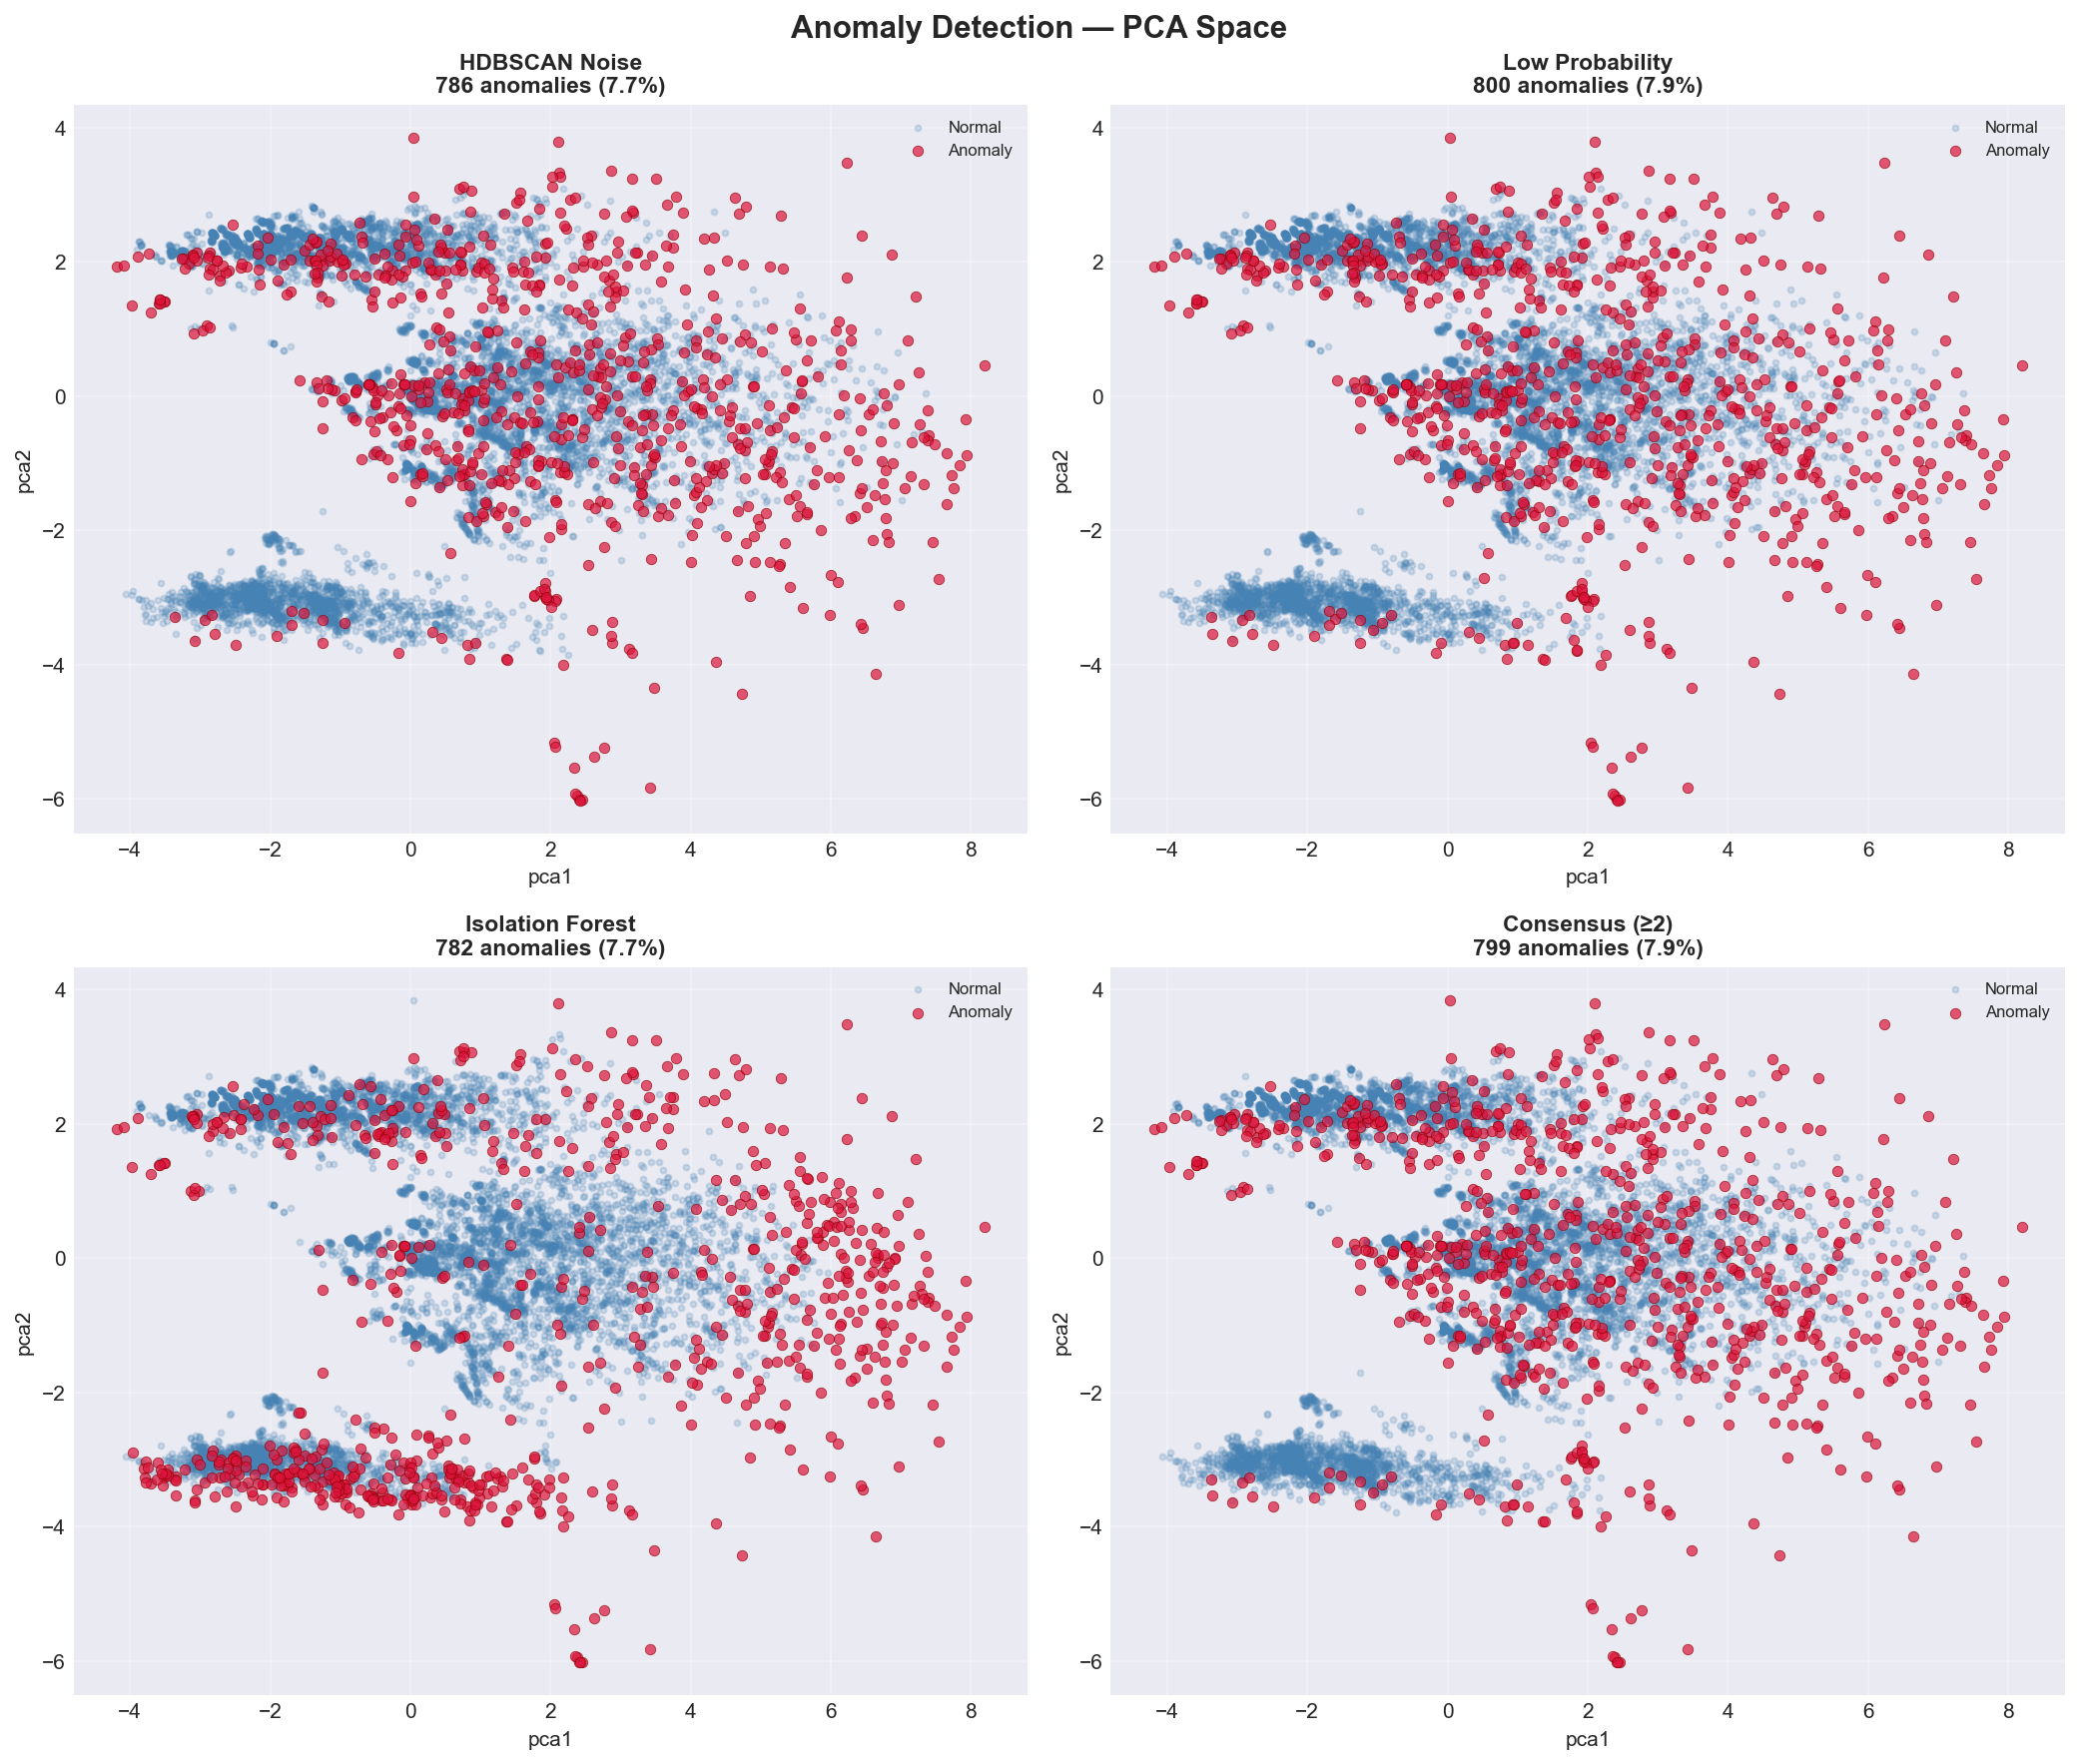

In [6]:
ipy_display(Image(filename=str(OUT / 'figures' / 'anomaly_pca_comparison.png')))

In [7]:
# Interactive: chọn phương pháp để xem
pca_cols = [c for c in results_df.columns if c.lower().startswith('pca')]
px, py = pca_cols[0], pca_cols[1]

method_col = 'is_anomaly_consensus'   # ← thay đổi nếu muốn xem phương pháp khác
method_label = 'Consensus (≥2 methods)'

fig, ax = plt.subplots(figsize=(10, 7))
normal  = results_df[results_df[method_col] == 0]
anomaly = results_df[results_df[method_col] == 1]

ax.scatter(normal[px],  normal[py],  c='steelblue', alpha=0.15, s=10, label=f'Normal ({len(normal):,})')
ax.scatter(anomaly[px], anomaly[py], c='crimson',   alpha=0.7,  s=30, label=f'Anomaly ({len(anomaly):,})',
           edgecolors='darkred', linewidths=0.5)

ax.set_xlabel(px, fontsize=11)
ax.set_ylabel(py, fontsize=11)
ax.set_title(f'PCA — {method_label}\n{len(anomaly):,} anomalies ({len(anomaly)/len(results_df):.2%})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Dung\AppData\Local\Temp\ipykernel_26640\2266362976.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Diễn Giải Năng Lượng

> Energy **không** dùng để phát hiện — chỉ dùng để **xác nhận ý nghĩa vật lý** của anomalies.

In [8]:
print('DIỄN GIẢI: NĂNG LƯỢNG CỦA ANOMALIES vs NORMAL')
print('=' * 65)
print(f'{"Phương pháp":<28} {"Anomaly":>10} {"Normal":>10} {"Diff":>8}  Diễn giải')
print('-' * 65)

for col, label in [
    ('is_hdbscan_noise',            'HDBSCAN Noise'),
    ('is_low_probability',          'Low Probability'),
    ('is_isolation_forest_anomaly', 'Isolation Forest'),
    ('is_anomaly_consensus',        'Consensus (≥2) ★'),
    ('is_anomaly_all',              'All 3 methods'),
]:
    a = results_df.loc[results_df[col] == 1, 'relative_energy']
    n = results_df.loc[results_df[col] == 0, 'relative_energy']
    diff = a.mean() - n.mean()
    interp = '↑ kém ổn định' if diff > 0.01 else '↓ ổn định hơn' if diff < -0.01 else '≈ tương đương'
    print(f'  {label:<26} {a.mean():>10.4f} {n.mean():>10.4f} {diff:>+8.4f}  {interp}')

DIỄN GIẢI: NĂNG LƯỢNG CỦA ANOMALIES vs NORMAL
Phương pháp                     Anomaly     Normal     Diff  Diễn giải
-----------------------------------------------------------------
  HDBSCAN Noise                  0.3743     0.3008  +0.0735  ↑ kém ổn định
  Low Probability                0.3725     0.3008  +0.0716  ↑ kém ổn định
  Isolation Forest               0.3441     0.3033  +0.0407  ↑ kém ổn định
  Consensus (≥2) ★               0.3727     0.3008  +0.0719  ↑ kém ổn định
  All 3 methods                  0.3777     0.3036  +0.0741  ↑ kém ổn định


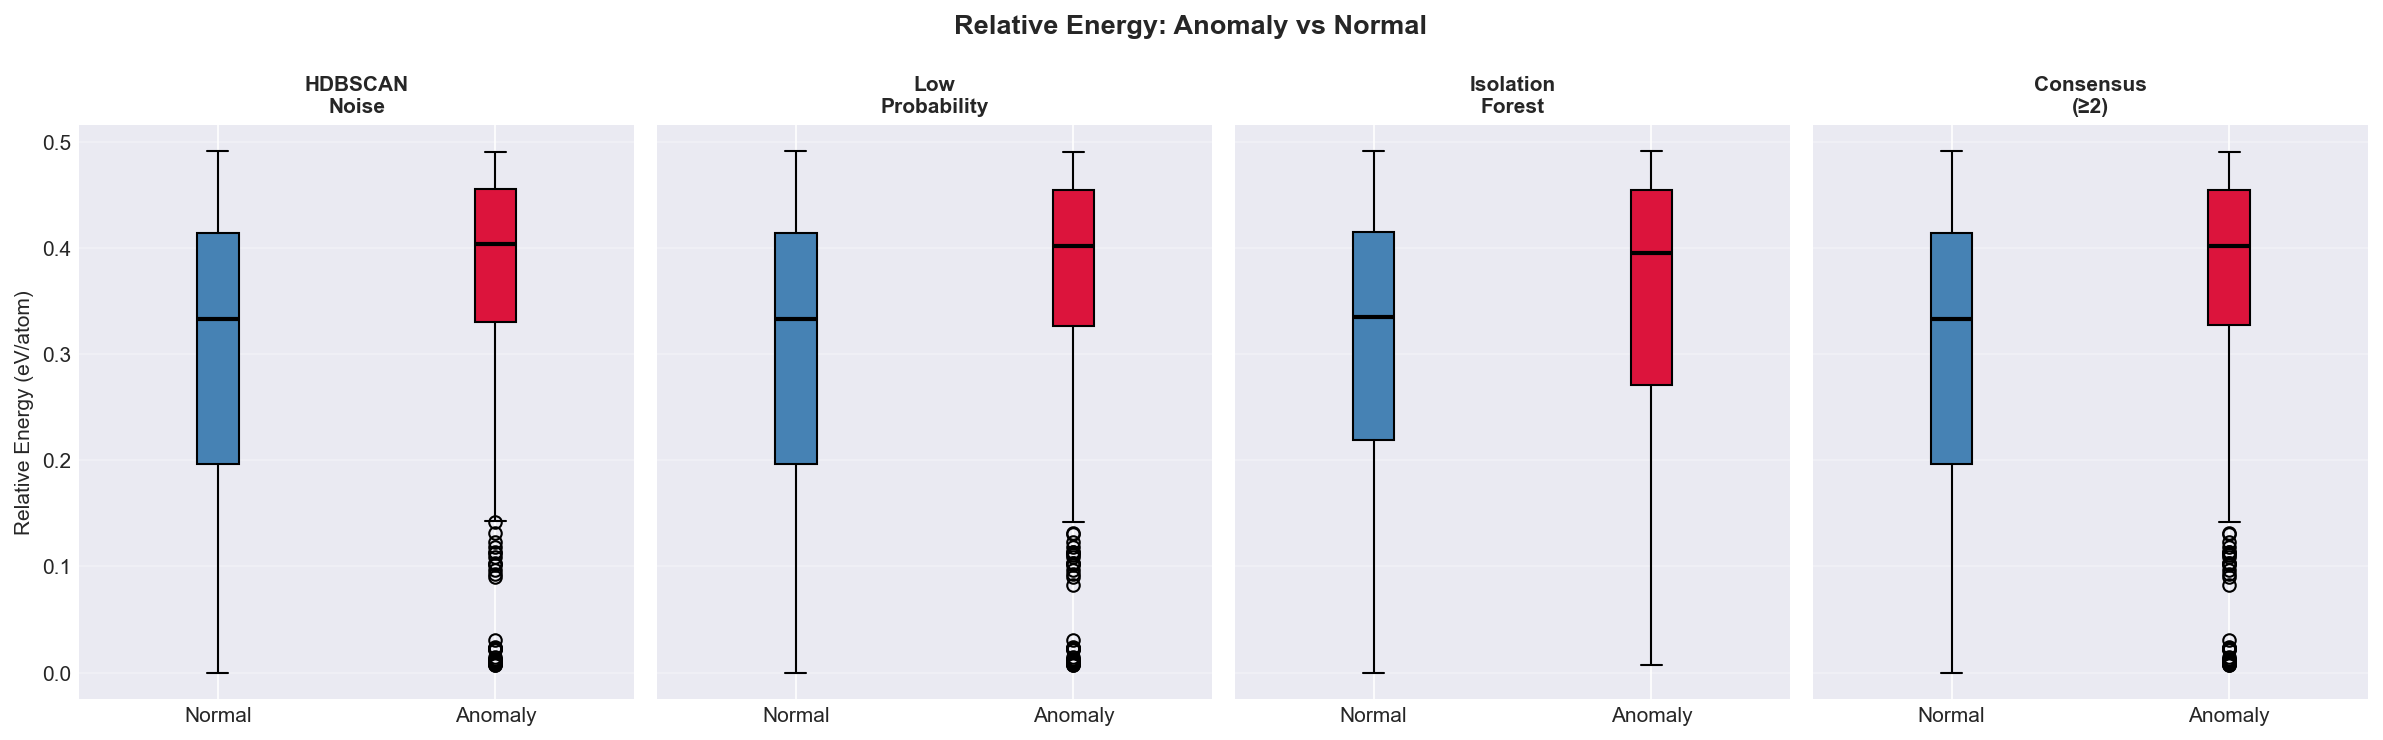

In [9]:
# Boxplot năng lượng
ipy_display(Image(filename=str(OUT / 'figures' / 'anomaly_energy_boxplot.png')))

In [10]:
# Histogram chi tiết cho Consensus
fig, ax = plt.subplots(figsize=(10, 5))

normal_e  = results_df.loc[results_df['is_anomaly_consensus'] == 0, 'relative_energy']
anomaly_e = results_df.loc[results_df['is_anomaly_consensus'] == 1, 'relative_energy']

ax.hist(normal_e,  bins=60, alpha=0.5, color='steelblue', label=f'Normal  (n={len(normal_e):,})',  density=True)
ax.hist(anomaly_e, bins=60, alpha=0.5, color='crimson',   label=f'Anomaly (n={len(anomaly_e):,})', density=True)
ax.axvline(normal_e.mean(),  color='steelblue', linestyle='--', lw=2, label=f'Normal mean = {normal_e.mean():.4f}')
ax.axvline(anomaly_e.mean(), color='crimson',   linestyle='--', lw=2, label=f'Anomaly mean = {anomaly_e.mean():.4f}')

diff = anomaly_e.mean() - normal_e.mean()
ax.set_xlabel('Relative Energy (eV/atom)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Phân bố Relative Energy — Consensus Anomalies\nChênh lệch: {diff:+.4f} eV/atom (anomaly kém ổn định hơn)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Dung\AppData\Local\Temp\ipykernel_26640\4246966044.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Isolation Forest Score

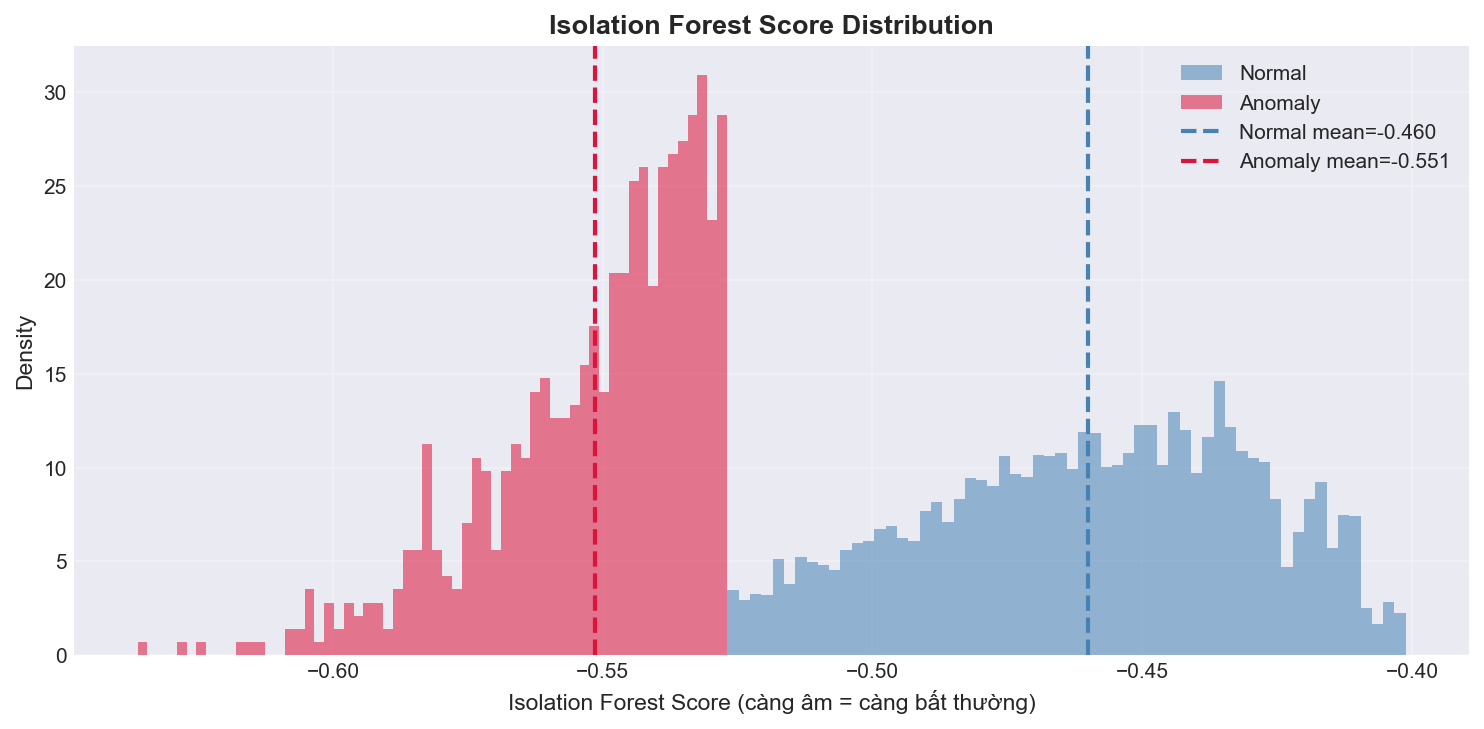

In [11]:
ipy_display(Image(filename=str(OUT / 'figures' / 'isolation_forest_score_distribution.png')))

In [12]:
print('ISOLATION FOREST SCORE — Thống kê')
print('=' * 50)
for label, mask in [('All', slice(None)),
                    ('Normal',  results_df['is_isolation_forest_anomaly'] == 0),
                    ('Anomaly', results_df['is_isolation_forest_anomaly'] == 1)]:
    s = results_df.loc[mask, 'isolation_forest_score']
    print(f'\n  {label} (n={len(s):,}):')
    print(s.describe().to_string())

ISOLATION FOREST SCORE — Thống kê

  All (n=10,153):
count    10153.000000
mean        -0.467047
std          0.038347
min         -0.636208
25%         -0.490115
50%         -0.461408
75%         -0.437433
max         -0.401163

  Normal (n=9,371):
count    9371.000000
mean       -0.460002
std         0.030280
min        -0.526886
25%        -0.482398
50%        -0.457966
75%        -0.436002
max        -0.401163

  Anomaly (n=782):
count    782.000000
mean      -0.551470
std        0.019546
min       -0.636208
25%       -0.562433
50%       -0.546339
75%       -0.535965
max       -0.526969


## 8. Overlap & Jaccard Similarity

In [13]:
methods = [
    ('is_hdbscan_noise',            'HDBSCAN Noise'),
    ('is_low_probability',          'Low Probability'),
    ('is_isolation_forest_anomaly', 'Isolation Forest'),
]

# Overlap count
overlap = pd.DataFrame(index=[m[1] for m in methods], columns=[m[1] for m in methods], dtype=float)
jaccard = pd.DataFrame(index=[m[1] for m in methods], columns=[m[1] for m in methods], dtype=float)

for c1, n1 in methods:
    for c2, n2 in methods:
        s1 = set(results_df.index[results_df[c1] == 1])
        s2 = set(results_df.index[results_df[c2] == 1])
        overlap.loc[n1, n2] = len(s1 & s2)
        jaccard.loc[n1, n2] = len(s1 & s2) / len(s1 | s2) if s1 | s2 else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(overlap, annot=True, fmt='.0f', cmap='Blues',
            linewidths=1, ax=axes[0], cbar_kws={'label': 'Số mẫu overlap'})
axes[0].set_title('Overlap Count', fontweight='bold')

sns.heatmap(jaccard, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=1, ax=axes[1], cbar_kws={'label': 'Jaccard Similarity'})
axes[1].set_title('Jaccard Similarity', fontweight='bold')

plt.suptitle('Mức độ đồng thuận giữa các phương pháp', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nJaccard Similarity:')
display(jaccard)


Jaccard Similarity:


C:\Users\Dung\AppData\Local\Temp\ipykernel_26640\591595996.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,HDBSCAN Noise,Low Probability,Isolation Forest
HDBSCAN Noise,1.000000,0.982500,0.328814
Low Probability,0.982500,1.000000,0.339543
Isolation Forest,0.328814,0.339543,1.000000


## 9. Chi Tiết Consensus Anomalies

In [14]:
print(f'Consensus anomalies (≥2 methods): {len(details_df):,}  ({len(details_df)/len(results_df):.2%})')
print(f'All 3 methods                   : {(details_df["anomaly_vote_count"]==3).sum():,}')
print()
display(details_df.head(20))

Consensus anomalies (≥2 methods): 799  (7.87%)
All 3 methods                   : 388



,material_id,anomaly_vote_count,is_hdbscan_noise,is_low_probability,is_isolation_forest_anomaly,relative_energy,energy,isolation_forest_score,hdbscan_cluster,hdbscan_probability
0,C-40124-9886-50,3,1,1,1,0.149600,-154.407385,-0.562110,-1,0.0
1,C-101121-514-62,3,1,1,1,0.335396,-154.221589,-0.566115,-1,0.0
2,C-57220-4652-35,3,1,1,1,0.236649,-154.320336,-0.560825,-1,0.0
3,C-192672-505-73,3,1,1,1,0.247646,-154.309339,-0.535107,-1,0.0
4,C-102862-9284-15,3,1,1,1,0.483362,-154.073623,-0.561041,-1,0.0
5,C-90863-258-34,3,1,1,1,0.103049,-154.453936,-0.559043,-1,0.0
6,C-194844-3110-45,3,1,1,1,0.468223,-154.088762,-0.555179,-1,0.0
7,C-137399-7235-5,3,1,1,1,0.380802,-154.176183,-0.570798,-1,0.0
8,C-72716-3406-49,3,1,1,1,0.241769,-154.315216,-0.533443,-1,0.0
9,C-177244-4718-32,3,1,1,1,0.374335,-154.182650,-0.537299,-1,0.0


In [15]:
# Phân tích cấu trúc tinh thể của anomalies
if 'crystal_system' in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (col, label) in zip(axes, [
        ('is_anomaly_consensus', 'Consensus Anomalies'),
        ('is_anomaly_all',       'All 3 Methods'),
    ]):
        cs = results_df.loc[results_df[col] == 1, 'crystal_system'].value_counts()
        cs_normal = results_df.loc[results_df[col] == 0, 'crystal_system'].value_counts(normalize=True)
        cs_anom   = results_df.loc[results_df[col] == 1, 'crystal_system'].value_counts(normalize=True)

        x = np.arange(len(cs_normal))
        w = 0.35
        ax.bar(x - w/2, cs_normal.reindex(cs_normal.index).values * 100,
               w, label='Normal', color='steelblue', alpha=0.7)
        ax.bar(x + w/2, cs_anom.reindex(cs_normal.index, fill_value=0).values * 100,
               w, label='Anomaly', color='crimson', alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(cs_normal.index, rotation=30, ha='right')
        ax.set_ylabel('Tỷ lệ (%)')
        ax.set_title(f'Crystal System — {label}', fontweight='bold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

C:\Users\Dung\AppData\Local\Temp\ipykernel_26640\501385707.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 10. Tổng Kết & Ý Nghĩa

In [16]:
consensus = results_df[results_df['is_anomaly_consensus'] == 1]
normal    = results_df[results_df['is_anomaly_consensus'] == 0]
diff      = consensus['relative_energy'].mean() - normal['relative_energy'].mean()

print('=' * 65)
print('TỔNG KẾT & Ý NGHĨA')
print('=' * 65)

print('''
1. PHƯƠNG PHÁP
    HDBSCAN Noise     : dựa trên mật độ cụm (26 features cấu trúc)
    Low Probability   : membership yếu, nằm ở biên cụm
    Isolation Forest  : 19 features cấu trúc gốc (không dùng energy)
   → Cả 3 đều nhất quán: anomaly = cấu trúc bất thường về hình học
''')

print(f'2. KẾT QUẢ')
print(f'   Consensus (≥2): {len(consensus):,} mẫu ({len(consensus)/len(results_df):.2%})')
print(f'   All 3 methods : {results_df["is_anomaly_all"].sum():,} mẫu ({results_df["is_anomaly_all"].mean():.2%})')

print(f'''
3. Ý NGHĨA VẬT LÝ
   Anomalies có relative_energy cao hơn {diff:+.4f} eV/atom
   → Cấu trúc kém ổn định về nhiệt động lực học
   → Hình học bất thường (lattice, bond, coordination) dẫn đến
     năng lượng cao hơn — nhất quán với lý thuyết

4. ỨNG DỤNG
   • Lọc dữ liệu trước khi train model → dùng is_anomaly_consensus
   • Nghiên cứu cấu trúc đặc biệt     → dùng is_anomaly_all
   • Khám phá rộng                     → dùng is_anomaly_any

5. OUTPUT FILES
   carbon24_anomaly_detection/
   ├── anomaly_detection_results.csv   (full, 26 cols)
   ├── anomaly_summary.csv             (energy comparison)
   ├── anomaly_method_comparison.csv   (method stats)
   ├── anomaly_details.csv             (consensus list)
   └── figures/  (4 PNG)
''')

TỔNG KẾT & Ý NGHĨA

1. PHƯƠNG PHÁP
    HDBSCAN Noise     : dựa trên mật độ cụm (26 features cấu trúc)
    Low Probability   : membership yếu, nằm ở biên cụm
    Isolation Forest  : 19 features cấu trúc gốc (không dùng energy)
   → Cả 3 đều nhất quán: anomaly = cấu trúc bất thường về hình học

2. KẾT QUẢ
   Consensus (≥2): 799 mẫu (7.87%)
   All 3 methods : 388 mẫu (3.82%)

3. Ý NGHĨA VẬT LÝ
   Anomalies có relative_energy cao hơn +0.0719 eV/atom
   → Cấu trúc kém ổn định về nhiệt động lực học
   → Hình học bất thường (lattice, bond, coordination) dẫn đến
     năng lượng cao hơn — nhất quán với lý thuyết

4. ỨNG DỤNG
   • Lọc dữ liệu trước khi train model → dùng is_anomaly_consensus
   • Nghiên cứu cấu trúc đặc biệt     → dùng is_anomaly_all
   • Khám phá rộng                     → dùng is_anomaly_any

5. OUTPUT FILES
   carbon24_anomaly_detection/
   ├── anomaly_detection_results.csv   (full, 26 cols)
   ├── anomaly_summary.csv             (energy comparison)
   ├── anomaly_method_comp